# Day 8 — Hybrid merge

Combines the classifier (signal 1) with the graph/ring evidence (signals 2 & 3). Day 7 found the graph layers aren't equally trustworthy — `identity_only` clusters score *below* the population baseline (0.57x lift), while `behavioral_only` clusters are the strongest signal (1.50x) — so this doesn't treat every cluster as equally "flagged"; it weights/filters by category.

**Leakage fix**: Day 7's category weights were computed using all 590K transactions' labels, including the 118K holdout. Reusing them here to score the holdout would be a soft leakage. This notebook recomputes the category weights using **only the 472,432-row train split**, then applies those clean weights to score the holdout — mirroring the same discipline already used for the classifier's own train/holdout split.

**Two combination strategies are tried and reported honestly, not just the one that "worked."** The first (rescale every score by its category weight, then re-optimize one global threshold) turned out to be net cost-*negative* — the mechanism is explained below, not hidden. The second (a narrow, opt-in "second look" at classifier-missed cases with strong ring evidence) is the one actually adopted, and it's reported honestly too: it does **not** beat the classifier on raw ₹ cost either, for a structural reason explained below — it's presented as an optional higher-recall mode for the analyst, tied to the product's sensitivity-slider concept, not as a cost win.

In [1]:
import sys, json
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from src.data import load_merged_train
from src.features import get_feature_lists
from src.split import apply_locked_split
from src.graph import load_graph
from src.cost import total_cost, find_optimal_threshold, DEFAULT_REVIEW_COST
from src.hybrid import (
    assign_cluster_categories, compute_category_weights, apply_hybrid_score,
    classifier_missed_hybrid_caught, second_look_mask, second_look_sensitivity_curve,
)

CLASSIFIER_THRESHOLD = 0.83  # locked on Day 4

In [2]:
train_full = load_merged_train()
train_df, holdout_df = apply_locked_split(train_full)
numeric_features, categorical_features = get_feature_lists(train_full)

X_holdout = holdout_df[numeric_features + categorical_features]
y_holdout = holdout_df['isFraud']
amounts_holdout = holdout_df['TransactionAmt']

model = joblib.load('../models/classifier_v2.joblib')
identity_graph = load_graph('../data/processed/identity_graph.pkl')
behavioral_graph = load_graph('../data/processed/behavioral_graph.pkl')

with open('../data/processed/cluster_partition.json') as f:
    partition_raw = json.load(f)
partition = {int(k): v for k, v in partition_raw.items()}

print('Loaded model, graphs, and partition for', len(partition), 'transactions.')

Loaded model, graphs, and partition for 590540 transactions.


## 1. Score the holdout, and sanity-check against the locked Day 4 result

In [3]:
classifier_proba = model.predict_proba(X_holdout)[:, 1]

with open('../results/classifier_final_metrics.json') as f:
    locked_classifier_metrics = json.load(f)

fn_count = int(((y_holdout == 1) & (classifier_proba < CLASSIFIER_THRESHOLD)).sum())
expected_fn = locked_classifier_metrics['confusion_matrix'][1][0]

print(f'False negatives at threshold {CLASSIFIER_THRESHOLD}: {fn_count} (expected: {expected_fn})')
assert fn_count == expected_fn, 'Freshly-scored holdout does not match the locked Day 4 result -- investigate before trusting anything below.'
print('Matches the locked Day 4 result.')

False negatives at threshold 0.83: 1408 (expected: 1408)
Matches the locked Day 4 result.


## 2. Assign cluster categories (train and holdout, separately)

Cluster size/edge-type is computed from the full partition (so a cluster split across train and holdout isn't miscounted), but categories are still only *used* separately per split — train categories to fit weights, holdout categories to score.

In [4]:
assert train_df['TransactionID'].isin(partition.keys()).all()
assert holdout_df['TransactionID'].isin(partition.keys()).all()

train_categories = assign_cluster_categories(train_df['TransactionID'], partition, identity_graph, behavioral_graph)
holdout_categories = assign_cluster_categories(holdout_df['TransactionID'], partition, identity_graph, behavioral_graph)

print('Train category counts:')
print(train_categories.value_counts())
print('\nHoldout category counts:')
print(holdout_categories.value_counts())
print(f"\n'neither' count -- train: {(train_categories == 'neither').sum()}, holdout: {(holdout_categories == 'neither').sum()} (expected ~0)")

Train category counts:
category
both               228278
isolated           179763
behavioral_only     36562
identity_only       27829
Name: count, dtype: int64

Holdout category counts:
category
both               57205
isolated           44797
behavioral_only     9100
identity_only       7006
Name: count, dtype: int64

'neither' count -- train: 0, holdout: 0 (expected ~0)


## 3. Fit category weights on train-only data

This confirms, on clean train-only data, the same picture Day 7 found on the full dataset — `behavioral_only` and `both` are the trustworthy categories; `identity_only` underperforms baseline. This is what justifies using those two specific categories (not all three) as the "trusted evidence" filter in Attempt 2 below.

In [5]:
train_weights = compute_category_weights(train_categories, train_df['isFraud'])

day7_full_dataset_weights = {'identity_only': 0.5710174348730569, 'behavioral_only': 1.5033981703710046, 'both': 1.206620914399601}

comparison = pd.DataFrame({
    'train_only': train_weights,
    'day7_full_dataset': pd.Series(day7_full_dataset_weights),
})
comparison['delta'] = comparison['train_only'] - comparison['day7_full_dataset']
comparison

,train_only,day7_full_dataset,delta
behavioral_only,1.507105,1.503398,0.003707
both,1.206297,1.206621,-0.000324
identity_only,0.575118,0.571017,0.004100
isolated,1.000000,NaN,NaN
neither,1.000000,NaN,NaN


## 4. Attempt 1 (rejected): global rescale + re-optimized threshold

`hybrid_score = classifier_proba * category_weight`, then find the cost-optimal threshold on that rescaled score, exactly like Day 4 did for the classifier alone.

In [6]:
hybrid_score = apply_hybrid_score(classifier_proba, holdout_categories, train_weights)
assert not np.isnan(hybrid_score).any()

classifier_cost = total_cost(y_holdout, classifier_proba, amounts_holdout, threshold=CLASSIFIER_THRESHOLD, review_cost=DEFAULT_REVIEW_COST)
print(f'Classifier-alone cost @ {CLASSIFIER_THRESHOLD}: Rs {classifier_cost:,.0f} (expected: Rs {locked_classifier_metrics["total_cost_rs"]:,.0f})')
assert abs(classifier_cost - locked_classifier_metrics['total_cost_rs']) < 1.0

hybrid_thresholds = np.arange(0.01, hybrid_score.max() + 0.02, 0.01)
hybrid_threshold, hybrid_cost, _ = find_optimal_threshold(
    y_holdout, hybrid_score, amounts_holdout, review_cost=DEFAULT_REVIEW_COST, thresholds=hybrid_thresholds
)

print(f'\nHybrid-optimal threshold: {hybrid_threshold:.2f}')
print(f'Hybrid cost @ optimal threshold: Rs {hybrid_cost:,.0f}')
print(f'Net vs. classifier alone: Rs {classifier_cost - hybrid_cost:,.0f} (negative = worse than the classifier alone)')

Classifier-alone cost @ 0.83: Rs 337,421 (expected: Rs 337,421)

Hybrid-optimal threshold: 0.95
Hybrid cost @ optimal threshold: Rs 392,838
Net vs. classifier alone: Rs -55,417 (negative = worse than the classifier alone)


In [7]:
coverage = holdout_categories.isin(['behavioral_only', 'both']).mean()
print(f'Share of the holdout with a >1x category weight (behavioral_only or both): {coverage:.1%}')
print(
    'Why this loses money: applying a 1.2-1.5x multiplier to that much of the population inflates '
    'apparent risk broadly, not selectively -- most of what gets boosted is still legitimate (3.5% '
    'population fraud rate), so it mostly creates new false positives. The cost-optimizer compensates '
    'by raising the threshold well past 0.83, which then costs real true positives among the '
    '"untouched" (isolated/neither) majority whose score never moved. Net: more reviews for less catch.'
)

Share of the holdout with a >1x category weight (behavioral_only or both): 56.1%
Why this loses money: applying a 1.2-1.5x multiplier to that much of the population inflates apparent risk broadly, not selectively -- most of what gets boosted is still legitimate (3.5% population fraud rate), so it mostly creates new false positives. The cost-optimizer compensates by raising the threshold well past 0.83, which then costs real true positives among the "untouched" (isolated/neither) majority whose score never moved. Net: more reviews for less catch.


## 5. Attempt 2 (adopted): an opt-in "second look," not a global rescale

Instead of touching every score, only ever *add* extra reviews for transactions the classifier already rejected (score < 0.83) that also carry `behavioral_only`/`both` evidence *and* clear a minimum probability floor. The classifier's own flagged set is never modified — so this **cannot** cause a regression on cases the classifier already got right, by construction.

The floor matters: without one, "classifier-missed + trusted category" is a huge, low-value population (63,645 transactions in this holdout, median classifier score 0.07) — reviewing all of them costs far more than the fraud recovered. The floor is a **sensitivity dial**, not a single fixed answer — swept below across a range, framed for the analyst to choose, not optimized to a $ target (see the honest note after the table).

In [8]:
lower_bounds = np.round(np.arange(0.05, CLASSIFIER_THRESHOLD, 0.05), 2)
curve = second_look_sensitivity_curve(
    y_holdout.to_numpy(), classifier_proba, holdout_categories, amounts_holdout.to_numpy(),
    classifier_threshold=CLASSIFIER_THRESHOLD, lower_bounds=lower_bounds, review_cost=DEFAULT_REVIEW_COST,
)
curve['lift_vs_population'] = curve['precision'] / (train_df['isFraud'].mean())
curve

,lower_bound,n_flagged,n_fraud_caught,precision,capture_rate_of_misses,fraud_amount_recovered_rs,review_cost_rs,net_rs,lift_vs_population
0,0.05,36216,849,0.023443,0.602983,150151.652,3621600.0,-3471448.348,0.669998
1,0.10,26162,799,0.030540,0.567472,140223.882,2616200.0,-2475976.118,0.872855
2,0.15,19574,755,0.038572,0.536222,133580.469,1957400.0,-1823819.531,1.102386
3,0.20,14963,712,0.047584,0.505682,124799.296,1496300.0,-1371500.704,1.359965
4,0.25,11654,668,0.057319,0.474432,116975.778,1165400.0,-1048424.222,1.638204
5,0.30,9251,622,0.067236,0.441761,108236.685,925100.0,-816863.315,1.921623
6,0.35,7340,577,0.078610,0.409801,102551.204,734000.0,-631448.796,2.246706
7,0.40,5876,527,0.089687,0.374290,91467.933,587600.0,-496132.067,2.563275
8,0.45,4715,480,0.101803,0.340909,84077.584,471500.0,-387422.416,2.909551
9,0.50,3769,439,0.116477,0.311790,79029.540,376900.0,-297870.460,3.328931


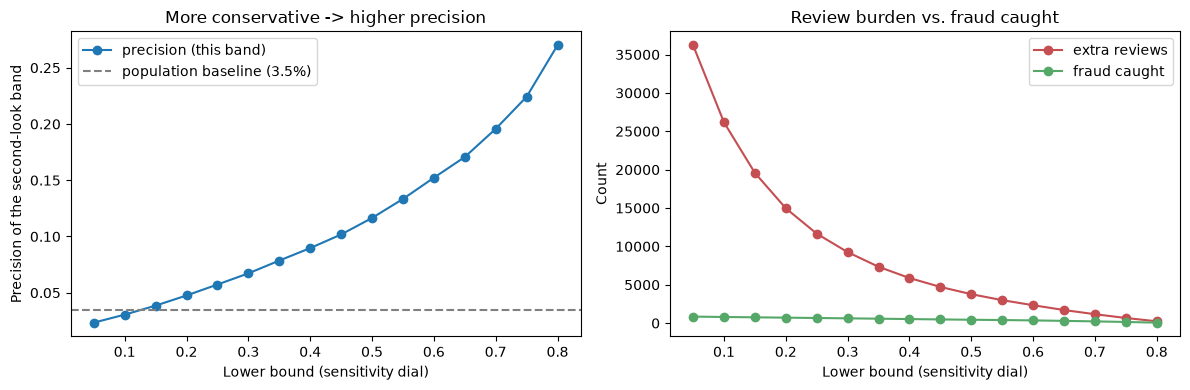

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(curve['lower_bound'], curve['precision'], marker='o', label='precision (this band)')
axes[0].axhline(train_df['isFraud'].mean(), color='gray', linestyle='--', label='population baseline (3.5%)')
axes[0].set_xlabel('Lower bound (sensitivity dial)')
axes[0].set_ylabel('Precision of the second-look band')
axes[0].set_title('More conservative -> higher precision')
axes[0].legend()

axes[1].plot(curve['lower_bound'], curve['n_flagged'], marker='o', color='#C44E52', label='extra reviews')
axes[1].plot(curve['lower_bound'], curve['n_fraud_caught'], marker='o', color='#55A868', label='fraud caught')
axes[1].set_xlabel('Lower bound (sensitivity dial)')
axes[1].set_ylabel('Count')
axes[1].set_title('Review burden vs. fraud caught')
axes[1].legend()

plt.tight_layout()
plt.show()

**Honest read**: `net_rs` is negative at every lower bound tested, including the most conservative one — this is a structural result, not a tuning failure. The classifier's own 0.83 threshold was *already* set (Day 4) at the point where expected fraud value ≈ ₹100 review cost. Anything the classifier scored below that is, by its own calibrated estimate, not worth a ₹100 review. For the graph signal to produce a net ₹ saving here, it would need to identify cases where that calibration is *wrong* by more than the fixed review cost — the fraud-rate lift is real (well above the 3.5% baseline at every lower bound), but not large enough in dollar terms to clear that bar. This is presented as an **optional, analyst-tunable higher-recall mode** (the sensitivity slider from the product design), not a cost-reducing default.

In [10]:
ILLUSTRATIVE_LOWER_BOUND = 0.50

illustrative_mask = second_look_mask(classifier_proba, holdout_categories, ILLUSTRATIVE_LOWER_BOUND, CLASSIFIER_THRESHOLD)
illustrative_row = curve[curve['lower_bound'] == ILLUSTRATIVE_LOWER_BOUND].iloc[0]

print(f'Illustrative sensitivity setting: lower_bound = {ILLUSTRATIVE_LOWER_BOUND}')
print(f"  Extra reviews: {int(illustrative_row['n_flagged']):,}")
print(f"  Fraud caught: {int(illustrative_row['n_fraud_caught'])} ({illustrative_row['capture_rate_of_misses']:.1%} of the classifier's {fn_count} misses)")
print(f"  Precision: {illustrative_row['precision']:.1%} ({illustrative_row['lift_vs_population']:.2f}x population baseline)")
print(f"  Net Rs (honest -- expected negative): {illustrative_row['net_rs']:,.0f}")

example_df = holdout_df.loc[illustrative_mask & (y_holdout == 1), ['TransactionID', 'TransactionAmt']].copy()
example_df['cluster_id'] = example_df['TransactionID'].map(partition)
example_df['category'] = holdout_categories.loc[example_df['TransactionID']].to_numpy()
example_df['classifier_proba'] = classifier_proba[illustrative_mask & (y_holdout == 1).to_numpy()]

print('\nExample fraud cases caught only by the second look:')
example_df.head(3)

Illustrative sensitivity setting: lower_bound = 0.5
  Extra reviews: 3,769
  Fraud caught: 439 (31.2% of the classifier's 1408 misses)
  Precision: 11.6% (3.33x population baseline)
  Net Rs (honest -- expected negative): -297,870

Example fraud cases caught only by the second look:


,TransactionID,TransactionAmt,cluster_id,category,classifier_proba
630,2987630,12.326,261,behavioral_only,0.611810
2059,2989059,100.000,1098,both,0.745904
2302,2989302,146.000,1744,both,0.641386


## Save hybrid merge results

In [11]:
hybrid_results = {
    'classifier_threshold': CLASSIFIER_THRESHOLD,
    'fn_count_validated': fn_count == expected_fn,
    'category_weights_train_only': train_weights,
    'category_weights_day7_full_dataset': day7_full_dataset_weights,
    'classifier_cost_rs': classifier_cost,
    'attempt_1_global_rescale': {
        'hybrid_threshold': hybrid_threshold,
        'hybrid_cost_rs': hybrid_cost,
        'net_vs_classifier_rs': classifier_cost - hybrid_cost,
        'boosted_coverage_share': coverage,
        'verdict': 'rejected -- net cost negative',
    },
    'attempt_2_second_look': {
        'sensitivity_curve': curve.to_dict(orient='records'),
        'illustrative_lower_bound': ILLUSTRATIVE_LOWER_BOUND,
        'illustrative_result': illustrative_row.to_dict(),
        'verdict': 'adopted as an opt-in analyst mode -- not a cost win, framed as a sensitivity dial',
    },
}

with open('../results/hybrid_metrics.json', 'w') as f:
    json.dump(hybrid_results, f, indent=2, default=str)

print('Saved to results/hybrid_metrics.json')

Saved to results/hybrid_metrics.json


## Takeaway

_Fill in after running: the mechanism behind Attempt 1's rejection, the sensitivity curve's shape (precision/capture-rate/review-burden tradeoff), the illustrative setting's numbers, and one honest sentence on why this is framed as an optional analyst mode rather than a default cost win._